# Demo

A demostration script for the ECLYPSE network simulator extension.

This script validates the implementation of the M/M/1 queuing model,
physical link parameters, and routing tables by simulating a "bottleneck"
scenario.
It sets up a topology (Sensor → Gateway → Cloud), defines traffic flows,
and measures the end-to-end packet delays to demonstrate the emergence of
queuing congestion.

In [1]:
import time
from eclypse.remote.service import Service
from mm1_infrastructure import MM1Infrastructure
from network_application import NetworkAwareApplication
from NetworkSimulation import NetworkSimulation
import pandas as pd
import matplotlib.pyplot as plt
import random
random.seed(42)

**DemoService** is a placeholder service to represent application endpoints (e.g. Sensors, Cloud).

In this network-focused simulation, services do not perform internal computation (CPU/RAM logic). They serve as anchors in the application graph to define the source and destination of network flows.

In [2]:
class DemoService(Service):
    def __init__(self, name):
        super().__init__(name)
        self.step_callback = None

    async def step(self):
        pass

The following script orchestrates the bottleneck simulation scenario.

Steps performed:
1. **Infrastructure setup**: Creates a 3-node network (Sensor, Gateway, Cloud). Configures a fast LAN link (100 mbps) and a slow WAN link (10 Mbps) to create a bottleneck.
2. **Application setup**: Defines an application with a flow from Sensor to Cloud.
3. **Routing**: Simulates OSPF convergence to populate routing tables.
4. **Simulation**: Sends a burst of packets and tracks their travel time hop-by-hop.
5. **Analysis**: Prints a table showing start times, arrival times, and queuing delays.

## Service Time (The Speed Limit)

We look at the physical limitations of the "Bottleneck" link.
- **The Constraints**: The link is limited to **10 Mbps** (10 million bits per second). Each packet we send is a fixed size of 1500 Bytes (which is $1500 \times 8 = 12000$ bits).
- **The Calculation**: To push one single packet onto the wire, the router requires a specific amount of time.

$Time = \frac{12000 \: bits}{10000000 \: bits/sec} = 0.0012 \: seconds = 1.2 \: ms$

This means that once the Gateway starts transmitting a packet, it is physically "busy" for the next **1,2 ms**. It cannot touch another packet during this window.

## Arrival Rate (The Traffic Jam)

We look at how the application is creating work.
- **The input**: the `inter_arrival_time` is configured to **0.0005** seconds (0.5 ms).
- **The Rate**: This implies we are effectively trying to push data at a rate of 24 Mbps (12000 bits/0.0005 s).
- **The Conflict**: We are asking the router to do a job every 0.5 ms, but the router takes 1.2 ms to finish that job.

## Accumulating "Debt"
This mismatch creates a guaranteed growing backlog. So for every single packet that arrives, the router falls further behind.

$Deficit \, per \, packet = Service \, Time (1.2 \, ms) - Arrival \, time (0.5 \,  ms) = 0.7 \, ms$

So we predict every time a new packet arrives, it will have to wait **0.7 ms longer** than the packet before it. This isn't random noise; it is a structural, linear accumulation of delay.

## Theoretical Calculation for the 100th Packet
Based on this linear accumulation model, we can estimate the **Queuing Delay ($W_q$) for the N-th packet. The 100th packet ($N = 100$) finds 99 packet ahead of it that have contributed to the creation of the queue.

$W_{q,100} \approx (N-1) \times Deficit$

$W_{q,100} \approx 99 \times 0.7 \: ms = 69.3 \: ms$

To this waiting delay, we must add its own service time (1.2 ms) and propagation delay (negligible in this context), bringing the theoretical Total Delay ($T_{tot}) to:

$T_{tot,100} = W_{q,100} + T_s \approx 69.3 + 1.2 = 70.5 \: ms$


In [3]:
from eclypse.placement.strategies import RandomStrategy
print("1. Setting up Infrastructure...")
infra = MM1Infrastructure("IoT_Network")
infra.add_node("Sensor")
infra.add_node("Gateway")
infra.add_node("Cloud")

# Fast Link (Sensor -> Gateway): 100 Mbps
infra.add_physical_link("Sensor", "Gateway", bandwidth_mbps=100, length_km=1)

# Slow Link (Gateway -> Cloud): 10 Mbps (THE BOTTLENECK)
infra.add_physical_link("Gateway", "Cloud", bandwidth_mbps=10, length_km=50)

infra.install_shortest_path_routes()

# Application Configuration
print("2. Setting up Application (Video Stream)...")
app = NetworkAwareApplication("VideoApp")

app.add_service(DemoService("Sensor"))
app.add_service(DemoService("Cloud"))

# STRESS TEST PARAMS:
# Packet Size = 1500 Byte -> Service Time su 10Mbps = 1.2 ms
# Rate = 1 pkt / tick.
# If Tick = 0.5 ms -> We send a packet every 0.5ms but we free every 1.2ms -> CONGESTION!
app.add_flow("Sensor", "Cloud", packet_size_bytes=1500, packets_per_tick=1)

# Simulation Setup
print("3. Initializing Simulation...")
sim = NetworkSimulation(infra)
strategy = RandomStrategy(seed=42)
sim.register(app, placement_strategy=strategy)

# Execution 
# Tick duration = 0.5 ms (0.0005 s)
# Duration = 100 Tick (a total of 50ms of traffic generated, but we will see congestion due to the bottleneck link)
df = sim.run_network_ticks(duration_ticks=100, tick_duration_s=0.0005)

1. Setting up Infrastructure...
--- Configuration of Routing Tables (OSPF simulation) ---
Routing tables installed on all nodes.
2. Setting up Application (Video Stream)...
Add edge flow Sensor->Cloud: 1 pkt/tick, size 1500B
3. Initializing Simulation...
15:52:07.875 | WARNING | SimulationConfig - Manual simulation required!
15:52:07.875 | WARNING | SimulationConfig - Use 'step()' to advance the simulation, and 'stop()' to interrupt it.
['Sensor', 'Gateway', 'Cloud']
['Sensor', 'Gateway', 'Cloud']
['Sensor', 'Gateway', 'Cloud']
['Sensor', 'Gateway', 'Cloud']
['Sensor', 'Gateway', 'Cloud']
['Sensor', 'Gateway', 'Cloud']
['Sensor', 'Gateway', 'Cloud']
['Sensor', 'Gateway', 'Cloud']
['Sensor', 'Gateway', 'Cloud']
['Sensor', 'Gateway', 'Cloud']
['Sensor', 'Gateway', 'Cloud']
['Sensor', 'Gateway', 'Cloud']
['Sensor', 'Gateway', 'Cloud']
['Sensor', 'Gateway', 'Cloud']
['Sensor', 'Gateway', 'Cloud']
['Sensor', 'Gateway', 'Cloud']
['Sensor', 'Gateway', 'Cloud']
['Sensor', 'Gateway', 'Cloud']
[

In [4]:
df

,Tick,Packet_ID,App,Src,Dst,Start_Time,End_Time,Total_Delay_ms,Hops_Count,Hops_Details
0,1,1,,Sensor,Cloud,0.0000,0.001316,1.315744,2,"[{'hop': 'Sensor->Gateway', 'processing_ms': 0..."
1,2,2,,Sensor,Cloud,0.0005,0.003817,3.317018,2,"[{'hop': 'Sensor->Gateway', 'processing_ms': 0..."
2,3,3,,Sensor,Cloud,0.0010,0.003897,2.897311,2,"[{'hop': 'Sensor->Gateway', 'processing_ms': 0..."
3,4,4,,Sensor,Cloud,0.0015,0.008847,7.347116,2,"[{'hop': 'Sensor->Gateway', 'processing_ms': 0..."
4,5,5,,Sensor,Cloud,0.0020,0.010244,8.244467,2,"[{'hop': 'Sensor->Gateway', 'processing_ms': 0..."
...,...,...,...,...,...,...,...,...,...,...
95,96,96,,Sensor,Cloud,0.0475,0.118012,70.511722,2,"[{'hop': 'Sensor->Gateway', 'processing_ms': 0..."
96,97,97,,Sensor,Cloud,0.0480,0.118909,70.908715,2,"[{'hop': 'Sensor->Gateway', 'processing_ms': 0..."
97,98,98,,Sensor,Cloud,0.0485,0.119639,71.139149,2,"[{'hop': 'Sensor->Gateway', 'processing_ms': 0..."
98,99,99,,Sensor,Cloud,0.0490,0.120770,71.769507,2,"[{'hop': 'Sensor->Gateway', 'processing_ms': 0..."


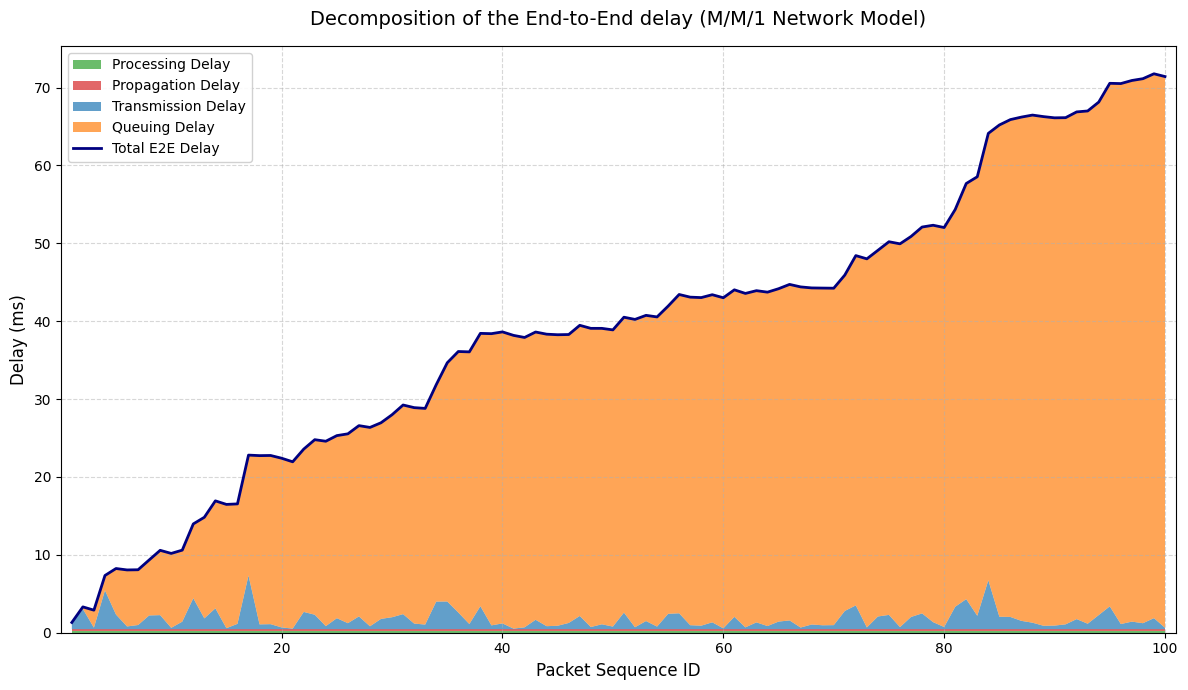


Breakdown of the last packet (ID 100):
- Processing:   0.20 ms
- Propagation:  0.26 ms
- Transmission: 0.19 ms
- Queuing:      70.77 ms
--------------------------------
= TOTAL:        71.41 ms


In [5]:
import matplotlib.pyplot as plt

# helper function to sum a specific metric across all hops for a given packet
def sum_metric_all_hops(hops_list, metric_name):
    if not isinstance(hops_list, list): return 0.0
    return sum(hop.get(metric_name, 0.0) for hop in hops_list)

# create new columns in the DataFrame for each delay component by summing across all hops
df['Total_Proc_ms'] = df['Hops_Details'].apply(lambda x: sum_metric_all_hops(x, 'processing_ms'))
df['Total_Prop_ms'] = df['Hops_Details'].apply(lambda x: sum_metric_all_hops(x, 'propagation_ms'))
df['Total_Trans_ms'] = df['Hops_Details'].apply(lambda x: sum_metric_all_hops(x, 'transmission_ms'))
df['Total_Queue_ms'] = df['Hops_Details'].apply(lambda x: sum_metric_all_hops(x, 'queue_ms'))

# create a stack plot to visualize the delay breakdown for each packet
plt.figure(figsize=(12, 7))

# We use plt.stackplot to create a stacked area chart where each layer represents a different delay component. 
# The order is important: we put the fixed delays at the bottom and the variable one (the queue) above.
plt.stackplot(
    df['Packet_ID'],
    df['Total_Proc_ms'],
    df['Total_Prop_ms'],
    df['Total_Trans_ms'],
    df['Total_Queue_ms'],
    labels=['Processing Delay', 'Propagation Delay', 'Transmission Delay', 'Queuing Delay'],
    colors=['#2ca02c', '#d62728', '#1f77b4', '#ff7f0e'], 
    alpha=0.7
)

# We add a line above everything to mark the Total Delay
plt.plot(df['Packet_ID'], df['Total_Delay_ms'], color='navy', linewidth=2, label='Total E2E Delay')

plt.title("Decomposition of the End-to-End delay (M/M/1 Network Model)", fontsize=14, pad=15)
plt.xlabel("Packet Sequence ID", fontsize=12)
plt.ylabel("Delay (ms)", fontsize=12)
plt.legend(loc='upper left', framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.5)

plt.margins(x=0.01)
plt.tight_layout()

plt.show()

# Final control print to see the relative weights on the last package
last_pkt = df.iloc[-1]
print(f"\nBreakdown of the last packet (ID {last_pkt['Packet_ID']}):")
print(f"- Processing:   {last_pkt['Total_Proc_ms']:.2f} ms")
print(f"- Propagation:  {last_pkt['Total_Prop_ms']:.2f} ms")
print(f"- Transmission: {last_pkt['Total_Trans_ms']:.2f} ms")
print(f"- Queuing:      {last_pkt['Total_Queue_ms']:.2f} ms")
print(f"--------------------------------")
print(f"= TOTAL:        {last_pkt['Total_Delay_ms']:.2f} ms")